In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity
from nltk.stem.snowball import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

import warnings
warnings.simplefilter('ignore')

from sklearn.preprocessing import StandardScaler


In [ ]:
df = pd.read_csv("final_df_final.csv")

In [ ]:
feature_cols = [
    "Grado NLGI Consistencia",
    "Viscosidad del Aceite Base a 40°C. cSt",
    "Penetración de Cono a 25°C, 0.1mm",
    "Punto de Gota, °C",
    "Estabilidad Mecánica, %",
    "Punto de Soldadura Cuatro Bolas, kgf",
    "Desgaste Cuatro Bolas, mm",
    "Carga Timken Ok, lb",
    "Resistencia al Lavado por Agua a 80°C, %",
    "Factor de Velocidad",
    "Temperatura de Servicio °C, min",
    "Temperatura de Servicio °C, max",
]


In [ ]:
X = df[feature_cols].copy()

In [ ]:
# Escalar los datos (para que ninguna variable domine)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # matriz de características técnicas

Cada fila de X_scaled es el vector:
$p_i = (NLGI, visc, penetracion, punto de gota,...)$

#### Calcular matriz de similitud coseno
$similitud(q, p_i) = \frac{q \cdot p_i}{\|q\| \|p_i\|} = \cos(\theta)$.

In [ ]:
# cosine_sim[i, j] = similitud de coseno entre la grasa i y la grasa j.
cosine_sim = cosine_similarity(X_scaled, X_scaled)

#### Función de recomendación (ranking por similitud)

Usa el índice del df como identificador

In [ ]:
df = df.reset_index(drop=True)

def recomendar_grasas(idx_grasa_consulta, top_n=5):
    """
    idx_grasa_consulta: índice de la grasa en df (0 a 50)
    top_n: número de recomendaciones a devolver
    """
    # vector de similitudes contra todas las demás
    sim_scores = list(enumerate(cosine_sim[idx_grasa_consulta]))

    # ordenar de mayor a menor similitud
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # quitar la propia grasa (primer elemento, similitud = 1)
    sim_scores = sim_scores[1:top_n+1]

    # índices de las grasas recomendadas
    grasa_indices = [i[0] for i in sim_scores]

    # devolver subset con info útil
    resultado = df.loc[grasa_indices, [
        "Aceite Base",
        "Espesante",
        "Grado NLGI Consistencia",
        "Viscosidad del Aceite Base a 40°C. cSt",
        "Punto de Gota, °C",
        "Punto de Soldadura Cuatro Bolas, kgf",
        "Desgaste Cuatro Bolas, mm",
        "Temperatura de Servicio °C, min",
        "Temperatura de Servicio °C, max",
        "color",
        "textura",
    ]].copy()

    # agregamos la similitud como columna
    resultado["similitud_coseno"] = [s[1] for s in sim_scores]

    return resultado


#### Ejemplo

In [ ]:
# Ver la grasa de consulta
df.loc[0]

# Ver recomendaciones similares a la grasa 0
recomendar_grasas(0, top_n=5)

,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,similitud_coseno
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,0.822725
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,0.796851
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,0.599167
32,Mineral HT,Complejo de Aluminio - Poliurea,3.0,680.0,260.0,620.0,0.48,5,150,Beige,Adherente,0.559968
11,Mineral HT,Complejo Sulfonato de Calcio,3.0,800.0,304.0,900.0,0.50,5,150,Negro,Adherente,0.538981


#### Recomendador basado en contenido (metadata técnica)

Aceite Base

Espesante

color

textura

descripcion

In [ ]:
# Crear la columna soup
# El soup es un texto que combina toda la metadata en una sola cadena.
df_meta = df.copy()

# Crear "soup" — metadata concatenada
df_meta["soup"] = (
    df_meta["Aceite Base"] + " " +
    df_meta["Espesante"] + " " +
    df_meta["color"] + " " +
    df_meta["textura"] + " " +
    df_meta["descripcion"]
)


In [ ]:
# Vectorizar el contenido (CountVectorizer)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

count = CountVectorizer(stop_words=None)
count_matrix = count.fit_transform(df_meta["soup"])

In [ ]:
# Calcular matriz de similitud coseno
cosine_sim_meta = cosine_similarity(count_matrix, count_matrix)

In [ ]:
# Crear índices para encontrar grasas por nombre
# necesita una columna que identifique cada grasa.
df_meta = df_meta.reset_index()
indices_meta = pd.Series(df_meta.index, index=df_meta.index)  # usa índice como id


In [ ]:
# Función de recomendador de grasas
def recomendar_grasas_metadata(idx_grasa, top_n=5):
    # obtener similitudes de esa grasa con todas
    sim_scores = list(enumerate(cosine_sim_meta[idx_grasa]))

    # ordenar de mayor a menor similitud
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # quitar la propia grasa (la primera es ella misma)
    sim_scores = sim_scores[1:top_n+1]

    # índices de las recomendadas
    grasa_indices = [i[0] for i in sim_scores]

    # devolver subset + similitud
    resultado = df_meta.loc[grasa_indices, [
        "Aceite Base", "Espesante", "color", "textura", "descripcion"
    ]].copy()

    resultado["similitud_coseno_metadata"] = [s[1] for s in sim_scores]

    return resultado


#### Probar el recomendador

Encuentra grasas con mismos espesantes, mismo aceite base, misma categoría funcional

Considera características cualitativas (color, textura)

Usa descripciones técnicas que mencionan:

- “carga extrema”
- “alta temperatura”
- “suave”
- “adherente”
- “multipropósito”


In [ ]:
recomendar_grasas_metadata(0, top_n=5) #devuelve las grasas más similares en formulación, apariencia y funcionalidad, según metadata textual y categórica

,Aceite Base,Espesante,color,textura,descripcion,similitud_coseno_metadata
12,Mineral Refinado,Complejo Sulfonato de Calcio,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.809095
13,Mineral Refinado,Complejo Sulfonato de Calcio,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.809095
39,Mineral HT,Complejo Sulfonato de Calcio,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.723043
40,Mineral HT,Complejo Sulfonato de Calcio,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.723043
41,Mineral HT,Complejo Sulfonato de Calcio,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.723043


#### Recomendador híbrido: integración numérico y basado en contenido

##### Preparar similitud numérica (técnica)

In [ ]:
df_num = df.copy()

feature_cols = [
    "Grado NLGI Consistencia",
    "Viscosidad del Aceite Base a 40°C. cSt",
    "Penetración de Cono a 25°C, 0.1mm",
    "Punto de Gota, °C",
    "Estabilidad Mecánica, %",
    "Punto de Soldadura Cuatro Bolas, kgf",
    "Desgaste Cuatro Bolas, mm",
    "Carga Timken Ok, lb",
    "Resistencia al Lavado por Agua a 80°C, %",
    "Factor de Velocidad",
    "Temperatura de Servicio °C, min",
    "Temperatura de Servicio °C, max",
]

X = df_num[feature_cols].copy()

# Rellenar NaN numéricos con la media
X = X.fillna(X.mean())

# Escalar
scaler_num = StandardScaler()
X_scaled = scaler_num.fit_transform(X)

# Similitud coseno numérica
sim_num = cosine_similarity(X_scaled, X_scaled)

##### Preparar similitud por metadata (contenido técnico)

In [ ]:
df_meta = df.copy()

# Crear soup de metadata técnica
df_meta["soup"] = (
    df_meta["Aceite Base"] + " " +
    df_meta["Espesante"] + " " +
    df_meta["color"] + " " +
    df_meta["textura"] + " " +
    df_meta["descripcion"]
)

# Vectorizar
count = CountVectorizer(stop_words=None)
count_matrix = count.fit_transform(df_meta["soup"])

# Similitud coseno por contenido
sim_meta = cosine_similarity(count_matrix, count_matrix)

##### Normalizar ambas similitudes y combinarlas (híbrido)

In [ ]:
# Como la similitud numérica puede tener valores negativos (por el StandardScaler), es buena idea normalizar cada matriz a 0-1
from sklearn.preprocessing import MinMaxScaler

# Normalizar matriz numérica a [0,1]
scaler_sim_num = MinMaxScaler()
sim_num_norm = scaler_sim_num.fit_transform(sim_num)

# Normalizar matriz de contenido a [0,1]
scaler_sim_meta = MinMaxScaler()
sim_meta_norm = scaler_sim_meta.fit_transform(sim_meta)

$$sim_{híbrida} = \alpha \cdot sim_{num\_norm} + (1 - \alpha) \cdot sim_{meta\_norm}$$

In [ ]:
def get_hybrid_row(idx, alpha=0.6):
    """
    Devuelve el vector de similitudes híbridas de la grasa idx con todas las demás.
    alpha controla qué tanto pesa la parte numérica (0–1)
    """
    return alpha * sim_num_norm[idx] + (1 - alpha) * sim_meta_norm[idx]

Alpha es el peso que controla cuánto contribuye cada tipo de similitud en el recomendador híbrido. Si alpha es cercano a 1 -> pesa más la similitud técnica. Cercano a 0 -> pesa más la similitud de metadata

##### Función de recomendación híbrida

Similar a get_recommendations de pelis, devuelve también las similitudes separadas

In [ ]:
df_hybrid = df.copy().reset_index(drop=True)

def recomendar_grasas_hibrido(idx_grasa, top_n=5, alpha=0.6):
    """
    idx_grasa: índice de la grasa en el DataFrame (0, 1, 2, ...)
    top_n: número de recomendaciones
    alpha: peso de la similitud numérica vs la de contenido
    """
    # vector de similitudes híbridas con todas las grasas
    hybrid_row = get_hybrid_row(idx_grasa, alpha=alpha)

    # armar lista (índice, similitud)
    sim_scores = list(enumerate(hybrid_row))

    # ordenar por similitud descendente
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # quitar la propia grasa (primero es idx_grasa con similitud máxima)
    sim_scores = [s for s in sim_scores if s[0] != idx_grasa][:top_n]

    # indices recomendados
    grasa_indices = [i[0] for i in sim_scores]

    # construir dataframe resultado
    resultado = df_hybrid.loc[grasa_indices, [
        "Aceite Base",
        "Espesante",
        "Grado NLGI Consistencia",
        "Viscosidad del Aceite Base a 40°C. cSt",
        "Punto de Gota, °C",
        "Punto de Soldadura Cuatro Bolas, kgf",
        "Desgaste Cuatro Bolas, mm",
        "Temperatura de Servicio °C, min",
        "Temperatura de Servicio °C, max",
        "color",
        "textura",
        "descripcion"
    ]].copy()

    # añadir columnas de similitud
    resultado["sim_num"] = sim_num_norm[idx_grasa, grasa_indices]
    resultado["sim_meta"] = sim_meta_norm[idx_grasa, grasa_indices]
    resultado["sim_hibrida"] = [s[1] for s in sim_scores]

    return resultado


In [ ]:
# Prueba
# ver la grasa base
df_hybrid.loc[0]

# ver recomendaciones híbridas para la grasa 0
recomendar_grasas_hibrido(0, top_n=5, alpha=0.6)


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,sim_num,sim_meta,sim_hibrida
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.899320,0.654546,0.801411
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.882285,0.654546,0.791189
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.749606,0.746952,0.748544
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.697738,0.746952,0.717424
11,Mineral HT,Complejo Sulfonato de Calcio,3.0,800.0,304.0,900.0,0.50,5,150,Negro,Adherente,El producto es una grasa lubricante de gran ad...,0.725439,0.569395,0.663022


##### Ejemplo de cómo cambian las recomendaciones con el valor de alpha

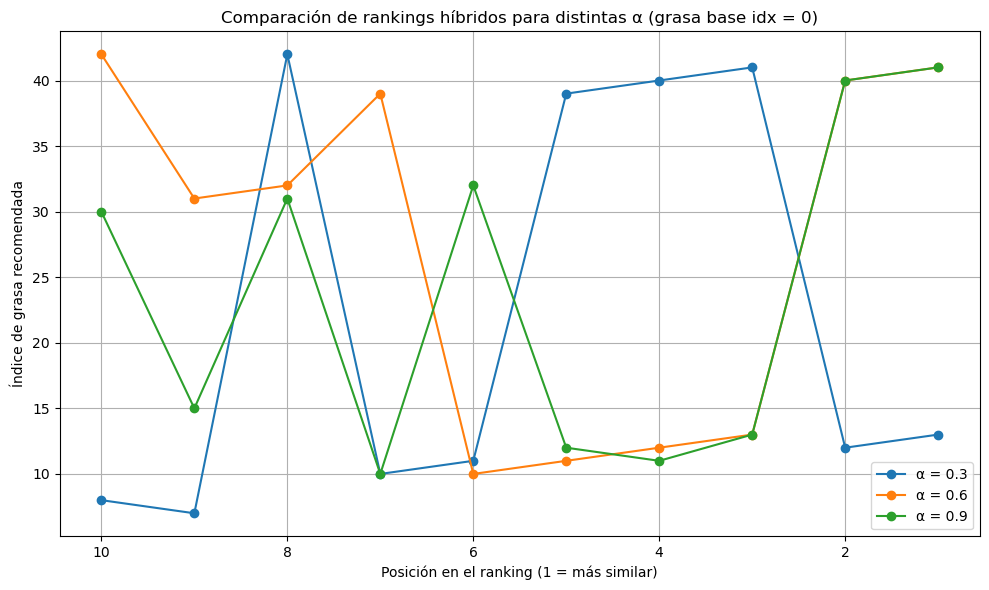

In [ ]:
# 5. Función para obtener fila híbrida
def get_hybrid_row(idx, alpha):
    return alpha * sim_num_norm[idx] + (1 - alpha) * sim_meta_norm[idx]

# 6. Función para obtener ranking de índices por similitud
def get_ranking_for_alpha(idx, alpha, top_n=10):
    row = get_hybrid_row(idx, alpha)
    sim_scores = list(enumerate(row))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]
    return [i for i, _ in sim_scores]

# Elegimos una grasa base (por ejemplo, índice 0)
idx_base = 0
alphas = [0.3, 0.6, 0.9]
rankings = {alpha: get_ranking_for_alpha(idx_base, alpha, top_n=10) for alpha in alphas}

# 7. Crear gráfico tipo "posición en el ranking" vs "índice de grasa"
plt.figure(figsize=(10, 6))

for alpha in alphas:
    y = rankings[alpha]
    x = list(range(1, len(y) + 1))  # posiciones 1..top_n
    plt.plot(x, y, marker='o', label=f'α = {alpha}', linestyle='-')

plt.xlabel('Posición en el ranking (1 = más similar)')
plt.ylabel('Índice de grasa recomendada')
plt.title(f'Comparación de rankings híbridos para distintas α (grasa base idx = {idx_base})')
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()  # opcional: para que la posición 1 quede más "importante" visualmente
plt.tight_layout()

plt.show()

El eje X es la posición en el ranking (1 = la grasa más similar a la grasa base, que fue la de índice 0).

El eje Y es el índice de la grasa recomendada en el DataFrame.

Cada línea corresponde a un valor de $\alpha$:

amarillo $\alpha$ = 0.3 → pesa más la metadata (aceite base, espesante, descripción…)

azul $\alpha$ = 0.6 → equilibrio 60% numérico, 40% metadata

verde $\alpha$ = 0.9 → casi todo el peso en propiedades técnicas numéricas

Si las tres curvas coincidieran, significaría que el ranking es casi el mismo sin importar $\alpha$.
Como ves, hay cambios en qué índices aparecen arriba dependiendo del valor de α → esto muestra que:

Cuando $\alpha$ es bajo (0.3), se priorizan grasas con formulación/descripcion parecida.

Cuando $\alpha$ es alto (0.9), se priorizan grasas con propiedades técnicas muy similares, aunque su “texto” sea distinto.

- El sistema permite ajustar la importancia relativa de desempeño técnico vs. formulación usando $\alpha$.

##### Código para imprimir tablas de recomendaciones híbridas ($\alpha$ =0.3, 0.6, 0.9)

In [ ]:
def recomendar_grasas_hibrido(idx_grasa, top_n=5, alpha=0.6):
    """
    idx_grasa: índice de la grasa en df
    top_n: número de recomendaciones
    alpha: peso de la similitud numérica vs metadata
    """
    hybrid_row = get_hybrid_row(idx_grasa, alpha=alpha)

    # ordenar de mayor a menor similitud
    sim_scores = list(enumerate(hybrid_row))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # excluir la propia grasa
    sim_scores = [s for s in sim_scores if s[0] != idx_grasa][:top_n]

    grasa_indices = [i for i, _ in sim_scores]

    resultado = df.loc[grasa_indices, [
        "Aceite Base",
        "Espesante",
        "Grado NLGI Consistencia",
        "Viscosidad del Aceite Base a 40°C. cSt",
        "Punto de Gota, °C",
        "Punto de Soldadura Cuatro Bolas, kgf",
        "Desgaste Cuatro Bolas, mm",
        "Temperatura de Servicio °C, min",
        "Temperatura de Servicio °C, max",
        "color",
        "textura",
        "descripcion"
    ]].copy()

    # añadir similitudes
    resultado["sim_num"] = sim_num_norm[idx_grasa, grasa_indices]
    resultado["sim_meta"] = sim_meta_norm[idx_grasa, grasa_indices]
    resultado["sim_hibrida"] = [s[1] for s in sim_scores]

    return resultado


# Mostrar recomendaciones para α=0.3, 0.6, 0.9


idx_base = 0  # Índice de la grasa a comparar

print("===== Recomendaciones híbridas (α = 0.3) =====")
display(recomendar_grasas_hibrido(idx_base, top_n=5, alpha=0.3))

print("\n===== Recomendaciones híbridas (α = 0.6) =====")
display(recomendar_grasas_hibrido(idx_base, top_n=5, alpha=0.6))

print("\n===== Recomendaciones híbridas (α = 0.9) =====")
display(recomendar_grasas_hibrido(idx_base, top_n=5, alpha=0.9))


===== Recomendaciones híbridas (α = 0.3) =====


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,sim_num,sim_meta,sim_hibrida
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.749606,0.746952,0.747748
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.697738,0.746952,0.732188
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.899320,0.654546,0.727978
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.882285,0.654546,0.722868
39,Mineral HT,Complejo Sulfonato de Calcio,0.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.594881,0.654546,0.636647



===== Recomendaciones híbridas (α = 0.6) =====


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,sim_num,sim_meta,sim_hibrida
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.899320,0.654546,0.801411
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.882285,0.654546,0.791189
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.749606,0.746952,0.748544
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.697738,0.746952,0.717424
11,Mineral HT,Complejo Sulfonato de Calcio,3.0,800.0,304.0,900.0,0.50,5,150,Negro,Adherente,El producto es una grasa lubricante de gran ad...,0.725439,0.569395,0.663022



===== Recomendaciones híbridas (α = 0.9) =====


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,sim_num,sim_meta,sim_hibrida
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.899320,0.654546,0.874843
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,0.882285,0.654546,0.859511
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.749606,0.746952,0.749340
11,Mineral HT,Complejo Sulfonato de Calcio,3.0,800.0,304.0,900.0,0.50,5,150,Negro,Adherente,El producto es una grasa lubricante de gran ad...,0.725439,0.569395,0.709835
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,0.697738,0.746952,0.702660


---


## Integración de competencia y recomputo del recomendador

En esta sección se combina el dataset `final_df_final` con las grasas de la competencia (Anderol, Solgelsal, Starplex) para que el recomendador funcione sobre un solo DataFrame unificado.

La idea es que cualquier índice (ya sea de interlub o de la competencia) pueda usarse como punto de partida y el sistema recomiende las 5 grasas más similares (técnica, metadata e híbrido).


In [ ]:
import pandas as pd

# ============================
# cargar datasets base y competencia
# ============================

# este ya lo tienes, pero lo vuelvo a cargar limpio para esta sección
df_base = pd.read_csv("/content/final_df_final.csv")

# competencia (ajusta los nombres si tus archivos tienen otros nombres)
df_anderol   = pd.read_csv("/content/Anderol.csv")
df_solgelsal = pd.read_csv("/content/Colgelsa - Hoja 1.csv")
df_starplex  = pd.read_csv("/content/Starplex.csv")
df_elkalub = pd.read_csv("/content/elkalub.csv")

print("df_base:", df_base.shape)
print("df_anderol:", df_anderol.shape)
print("df_solgelsal:", df_solgelsal.shape)
print("df_starplex:", df_starplex.shape)
print("df_elkalub:", df_elkalub.shape)


print("\nColumnas df_base:")
print(df_base.columns.tolist())

print("\nColumnas df_anderol:")
print(df_anderol.columns.tolist())

print("\nColumnas df_solgelsal:")
print(df_solgelsal.columns.tolist())

print("\nColumnas df_starplex:")
print(df_starplex.columns.tolist())

print("\nColumnas df_elkalub:")
print(df_elkalub.columns.tolist())


df_base: (51, 18)
df_anderol: (1, 39)
df_solgelsal: (2, 39)
df_starplex: (1, 39)

Columnas df_base:
['Unnamed: 0', 'Aceite Base', 'Espesante', 'Grado NLGI Consistencia', 'Viscosidad del Aceite Base a 40°C. cSt', 'Penetración de Cono a 25°C, 0.1mm', 'Punto de Gota, °C', 'Estabilidad Mecánica, %', 'Punto de Soldadura Cuatro Bolas, kgf', 'Desgaste Cuatro Bolas, mm', 'Carga Timken Ok, lb', 'Resistencia al Lavado por Agua a 80°C, %', 'Factor de Velocidad', 'Temperatura de Servicio °C, min', 'Temperatura de Servicio °C, max', 'descripcion', 'color', 'textura']

Columnas df_anderol:
['Aceite Base', 'Espesante', 'Grado NLGI Consistencia', 'Viscosidad del Aceite Base a 40âˆžC. cSt', 'PenetraciÃ›n de Cono a 25âˆžC, 0.1mm', 'Punto de Gota, âˆžC', 'Estabilidad MecÂ·nica, %', 'Punto de Soldadura Cuatro Bolas, kgf', 'Desgaste Cuatro Bolas, mm', 'Indice de Carga-Desgaste', 'Carga Timken Ok, lb', 'Resistencia al Lavado por Agua a 80âˆžC, %', 'Corrion EMCOR', 'CorrosiÃ›n al Cobre', 'Prueba FZG', 'Regis

Empresa
interlub    51
Name: count, dtype: int64
Empresa
Anderol    1
Name: count, dtype: int64
Empresa
Solgelsal    2
Name: count, dtype: int64
Empresa
Starplex    1
Name: count, dtype: int64
---

Corrige automáticamente los nombres rotos de columnas

Se queda solo con las columnas que sí nos importan para el recomendador

In [ ]:
# ============================
# 2. Normalización de nombres de columnas
# ============================

def limpiar_columnas(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace("âˆž", "°", regex=False)
        .str.replace("∞", "°", regex=False)
        .str.replace("Ã›", "ó", regex=False)
        .str.replace("Û", "ó", regex=False)
        .str.replace("Â·", "á", regex=False)
        .str.replace("·", "á", regex=False)
        .str.replace("Ò", "ñ", regex=False)
        .str.replace("µ", "u", regex=False)
        .str.strip()
    )
    return df

df_base      = limpiar_columnas(df_base)
df_anderol   = limpiar_columnas(df_anderol)
df_solgelsal = limpiar_columnas(df_solgelsal)
df_starplex  = limpiar_columnas(df_starplex)
df_elkalub =  limpiar_columnas(df_elkalub)

print("Columnas limpias df_base:")
print(df_base.columns.tolist())

print("\nColumnas limpias df_anderol:")
print(df_anderol.columns.tolist())

print("\nColumnas limpias df_solgelsal:")
print(df_solgelsal.columns.tolist())

print("\nColumnas limpias df_starplex:")
print(df_starplex.columns.tolist())


# ============================
# 3. Selección de columnas estándar para el recomendador
# ============================

columnas_modelo = [
    "Aceite Base",
    "Espesante",
    "Grado NLGI Consistencia",
    "Viscosidad del Aceite Base a 40°C. cSt",
    "Penetración de Cono a 25°C, 0.1mm",
    "Punto de Gota, °C",
    "Estabilidad Mecánica, %",
    "Punto de Soldadura Cuatro Bolas, kgf",
    "Desgaste Cuatro Bolas, mm",
    "Carga Timken Ok, lb",
    "Resistencia al Lavado por Agua a 80°C, %",
    "Factor de Velocidad",
    "Temperatura de Servicio °C, min",
    "Temperatura de Servicio °C, max",
    "descripcion",
    "color",
    "textura"
]

df_base_modelo      = df_base[columnas_modelo].copy()
df_anderol_modelo   = df_anderol[columnas_modelo].copy()
df_solgelsal_modelo = df_solgelsal[columnas_modelo].copy()
df_starplex_modelo  = df_starplex[columnas_modelo].copy()
df_elkalub_modelo  = df_elkalub[columnas_modelo].copy()

print("\nShapes después de estandarizar:")
print("df_base_modelo:", df_base_modelo.shape)
print("df_anderol_modelo:", df_anderol_modelo.shape)
print("df_solgelsal_modelo:", df_solgelsal_modelo.shape)
print("df_starplex_modelo:", df_starplex_modelo.shape)
print("df_elkalub_modelo:", df_elkalub_modelo.shape)


Columnas limpias df_base:
['Unnamed: 0', 'Aceite Base', 'Espesante', 'Grado NLGI Consistencia', 'Viscosidad del Aceite Base a 40°C. cSt', 'Penetración de Cono a 25°C, 0.1mm', 'Punto de Gota, °C', 'Estabilidad Mecánica, %', 'Punto de Soldadura Cuatro Bolas, kgf', 'Desgaste Cuatro Bolas, mm', 'Carga Timken Ok, lb', 'Resistencia al Lavado por Agua a 80°C, %', 'Factor de Velocidad', 'Temperatura de Servicio °C, min', 'Temperatura de Servicio °C, max', 'descripcion', 'color', 'textura']

Columnas limpias df_anderol:
['Aceite Base', 'Espesante', 'Grado NLGI Consistencia', 'Viscosidad del Aceite Base a 40°C. cSt', 'Penetración de Cono a 25°C, 0.1mm', 'Punto de Gota, °C', 'Estabilidad Mecánica, %', 'Punto de Soldadura Cuatro Bolas, kgf', 'Desgaste Cuatro Bolas, mm', 'Indice de Carga-Desgaste', 'Carga Timken Ok, lb', 'Resistencia al Lavado por Agua a 80°C, %', 'Corrion EMCOR', 'Corrosión al Cobre', 'Prueba FZG', 'Registro NSF', 'Solidos Totales, %', 'TamaÃ’o de Particula, Âu', 'Bombeabilidad', 

Le pone etiqueta de marca a cada dataset

In [ ]:
# ============================
# 4. Agregar columna Empresa (marca)
# ============================

df_base_modelo["Empresa"] = "Interlub"
df_anderol_modelo["Empresa"] = "Anderol"
df_solgelsal_modelo["Empresa"] = "Solgelsal"
df_starplex_modelo["Empresa"] = "Starplex"
df_elkalub_modelo["Empresa"] = "Elkalub"

print(df_base_modelo["Empresa"].value_counts())
print(df_anderol_modelo["Empresa"].value_counts())
print(df_solgelsal_modelo["Empresa"].value_counts())
print(df_starplex_modelo["Empresa"].value_counts())
print(df_elkalub_modelo["Empresa"].value_counts())

Empresa
Interlub    51
Name: count, dtype: int64
Empresa
Anderol    1
Name: count, dtype: int64
Empresa
Solgelsal    2
Name: count, dtype: int64
Empresa
Starplex    1
Name: count, dtype: int64


In [ ]:
# ============================
# 5. Unión total de los datasets y reset de índices
# ============================

df_total = pd.concat([
    df_base_modelo,
    df_anderol_modelo,
    df_solgelsal_modelo,
    df_starplex_modelo,
    df_elkalub_modelo
], ignore_index=True)

# Aseguramos que el índice sea universal (0, 1, 2, ..., N)
df_total = df_total.reset_index(drop=True)

print("Shape de df_total:", df_total.shape)
print("\nConteo por Empresa en df_total:")
print(df_total["Empresa"].value_counts())

print("\nPrimeras filas de df_total:")
df_total.head()


Shape de df_total: (55, 18)

Conteo por Empresa en df_total:
Empresa
Interlub     51
Solgelsal     2
Anderol       1
Starplex      1
Name: count, dtype: int64

Primeras filas de df_total:


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Penetración de Cono a 25°C, 0.1mm","Punto de Gota, °C","Estabilidad Mecánica, %","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Carga Timken Ok, lb","Resistencia al Lavado por Agua a 80°C, %",Factor de Velocidad,"Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",descripcion,color,textura,Empresa
0,Semi-Sintetico,Complejo Sulfonato de Calcio,2.0,680.0,279.0,304.0,1.07,500.0,0.48,60.0,0.58,200000.0,5,220,El producto es grasa lubricante de servicio pe...,CafÃ©,Suave,Interlub
1,Mineral HT,Complejo Sulfonato de Calcio,1.5,460.0,300.0,304.0,2.60,900.0,0.50,70.0,3.00,300000.0,-30,150,El producto es una grasa lubricante de gran ad...,Negro,Adherente,Interlub
2,Mineral HT,Complejo Sulfonato de Calcio,2.0,460.0,280.0,300.0,10.00,500.0,0.48,45.0,3.00,350000.0,-10,150,El producto es una grasa lubricante de gran ad...,Negro,Adherente,Interlub
3,Mineral HT,Complejo Sulfonato de Calcio,2.0,220.0,280.5,300.0,5.00,500.0,0.45,45.0,3.00,350000.0,-15,150,El producto es una grasa lubricante elaborada ...,Ambar,Suave,Interlub
4,Mineral HT,Complejo de Aluminio - Poliurea,1.5,680.0,295.0,260.0,6.50,620.0,0.48,50.0,1.45,350000.0,-5,150,El producto es un grasa lubricante con propied...,Negro,Adherente,Interlub


Toma solo columnas numéricas del modelo

Rellena NaN

Escala

Genera la matriz de similitud para TODAS las grasas (incluida competencia)

In [28]:
# ============================
# 6. Similitud numérica con df_total (versión robusta)
# ============================
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Grado NLGI Consistencia",
    "Viscosidad del Aceite Base a 40°C. cSt",
    "Penetración de Cono a 25°C, 0.1mm",
    "Punto de Gota, °C",
    "Estabilidad Mecánica, %",
    "Punto de Soldadura Cuatro Bolas, kgf",
    "Desgaste Cuatro Bolas, mm",
    "Carga Timken Ok, lb",
    "Resistencia al Lavado por Agua a 80°C, %",
    "Factor de Velocidad",
    "Temperatura de Servicio °C, min",
    "Temperatura de Servicio °C, max",
]

# 1. Extraer columnas
X_num = df_total[feature_cols].copy()

# 2. Forzar todas a numéricas (lo que no se pueda -> NaN)
for col in feature_cols:
    X_num[col] = pd.to_numeric(X_num[col], errors="coerce")

# 3. Rellenar NaN con la media
X_num = X_num.fillna(X_num.mean())

# 4. Escalar
scaler_num = StandardScaler()
X_num_scaled = scaler_num.fit_transform(X_num)

# 5. Similitud coseno numérica
sim_num = cosine_similarity(X_num_scaled, X_num_scaled)

print("Shape matriz numérica:", sim_num.shape)


Shape matriz numérica: (55, 55)


55 grasas totales
Todas se comparan contra todas
Incluye interlub + las 3 competencias
Parte numérica del recomendador 100% lista

In [29]:
# ============================
# 7. Similitud por METADATA (texto cualitativo)
# ============================

df_meta = df_total.copy()

# Crear columna soup con metadata concatenada
df_meta["soup"] = (
    df_meta["Aceite Base"].astype(str) + " " +
    df_meta["Espesante"].astype(str) + " " +
    df_meta["color"].astype(str) + " " +
    df_meta["textura"].astype(str) + " " +
    df_meta["descripcion"].astype(str)
)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

count = CountVectorizer(stop_words=None)
count_matrix = count.fit_transform(df_meta["soup"])

# Matriz de similitud por contenido
sim_meta = cosine_similarity(count_matrix, count_matrix)

print("Shape matriz metadata:", sim_meta.shape)


Shape matriz metadata: (55, 55)


on esto ya tienes los dos cerebros del recomendador funcionando:

Similitud numérica → (55, 55)

Similitud por metadata → (55, 55)

In [30]:
# ============================
# 8. Normalización y mezcla híbrida
# ============================

from sklearn.preprocessing import MinMaxScaler

# Normalizar similitud numérica
scaler_sim_num = MinMaxScaler()
sim_num_norm = scaler_sim_num.fit_transform(sim_num)

# Normalizar similitud por metadata
scaler_sim_meta = MinMaxScaler()
sim_meta_norm = scaler_sim_meta.fit_transform(sim_meta)

# Función para obtener fila híbrida
def get_hybrid_row(idx, alpha=0.6):
    """
    idx: índice de la grasa base
    alpha: peso de la similitud numérica (0–1)
    """
    return alpha * sim_num_norm[idx] + (1 - alpha) * sim_meta_norm[idx]

print("Similitud híbrida lista ")


Similitud híbrida lista 


In [31]:
# ============================
# 9. Recomendador híbrido final (Interlub + Competencia)
# ============================

df_hybrid = df_total.copy().reset_index(drop=True)

def recomendar_grasas_hibrido_competencia(idx_grasa, top_n=5, alpha=0.6):
    """
    idx_grasa: índice de la grasa en df_total (0 a 54)
    top_n: número de recomendaciones
    alpha: peso de la similitud numérica vs metadata
    """

    # obtener vector de similitudes híbridas
    hybrid_row = get_hybrid_row(idx_grasa, alpha=alpha)

    # crear ranking (índice, similitud)
    sim_scores = list(enumerate(hybrid_row))

    # ordenar de mayor a menor
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # quitar la propia grasa
    sim_scores = [s for s in sim_scores if s[0] != idx_grasa][:top_n]

    # índices recomendados
    grasa_indices = [i for i, _ in sim_scores]

    # armar resultado
    resultado = df_hybrid.loc[grasa_indices, [
        "Aceite Base",
        "Espesante",
        "Grado NLGI Consistencia",
        "Viscosidad del Aceite Base a 40°C. cSt",
        "Punto de Gota, °C",
        "Punto de Soldadura Cuatro Bolas, kgf",
        "Desgaste Cuatro Bolas, mm",
        "Temperatura de Servicio °C, min",
        "Temperatura de Servicio °C, max",
        "color",
        "textura",
        "descripcion",
        "Empresa"
    ]].copy()

    # agregar similitudes
    resultado["sim_num"] = sim_num_norm[idx_grasa, grasa_indices]
    resultado["sim_meta"] = sim_meta_norm[idx_grasa, grasa_indices]
    resultado["sim_hibrida"] = [s[1] for s in sim_scores]

    return resultado


primera prueba con interlub

In [32]:
df_hybrid.loc[0]
recomendar_grasas_hibrido_competencia(0, top_n=5, alpha=0.6)


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,Empresa,sim_num,sim_meta,sim_hibrida
41,Mineral HT,Complejo Sulfonato de Calcio,2.0,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,Interlub,0.884500,0.654546,0.792519
40,Mineral HT,Complejo Sulfonato de Calcio,1.5,1500.0,304.0,620.0,0.45,-5,190,Ambar,Adherente,El producto es una grasa lubricante de servici...,Interlub,0.862059,0.654546,0.779054
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,Interlub,0.709271,0.746952,0.724344
11,Mineral HT,Complejo Sulfonato de Calcio,3.0,800.0,304.0,900.0,0.50,5,150,Negro,Adherente,El producto es una grasa lubricante de gran ad...,Interlub,0.738112,0.569395,0.670625
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,Interlub,0.618525,0.746952,0.669896


anderol indice 51

In [33]:
df_hybrid.loc[51]
recomendar_grasas_hibrido_competencia(51, top_n=5, alpha=0.6)


,Aceite Base,Espesante,Grado NLGI Consistencia,Viscosidad del Aceite Base a 40°C. cSt,"Punto de Gota, °C","Punto de Soldadura Cuatro Bolas, kgf","Desgaste Cuatro Bolas, mm","Temperatura de Servicio °C, min","Temperatura de Servicio °C, max",color,textura,descripcion,Empresa,sim_num,sim_meta,sim_hibrida
54,Mineral,Complejo de Litio,2.0,220.0,255,315.0,0.45,-40,177,Rojo,Pegajosa,"Grasa EP NLGI 2, base mineral ISO VG 220 y esp...",Starplex,0.746600,0.198561,0.527384
13,Mineral Refinado,Complejo Sulfonato de Calcio,2.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,Interlub,0.783717,0.102274,0.511140
12,Mineral Refinado,Complejo Sulfonato de Calcio,1.0,460.0,304.0,500.0,0.48,-20,190,CafÃ© Claro,Suave,El producto es una grasa lubricante de servici...,Interlub,0.681347,0.102274,0.449718
3,Mineral HT,Complejo Sulfonato de Calcio,2.0,220.0,300.0,500.0,0.45,-15,150,Ambar,Suave,El producto es una grasa lubricante elaborada ...,Interlub,0.748877,0.000000,0.449326
45,Mineral HC,Complejo de Litio,2.0,220.0,280.0,315.0,0.50,-20,90,Beige,Suave Adherente,El producto es una grasa formulada con aceite ...,Interlub,0.577706,0.164006,0.412226


---

## Recomendador por Nombre de Grasa

En esta sección se implementa una función que permite utilizar el nombre de una grasa como entrada en lugar del índice numérico. Esto facilita la interacción con el sistema, ya que el usuario no necesita conocer la posición exacta del producto dentro del DataFrame, sino únicamente su nombre comercial o identificador.


In [38]:
# ==========================================================
# RECOMENDADOR POR NOMBRE + SLIDER INTERACTIVO
# ==========================================================

import ipywidgets as widgets
from IPython.display import display, clear_output

# ----------------------------------------------------------
# 1. Crear nombre legible para cada grasa
# ----------------------------------------------------------

df_total = df_total.reset_index(drop=True)

df_total["nombre_legible"] = (
    df_total["Empresa"].astype(str) + " | " +
    df_total["Aceite Base"].astype(str) + " | " +
    df_total["Espesante"].astype(str) + " | NLGI " +
    df_total["Grado NLGI Consistencia"].astype(str)
)

nombre_col = "nombre_legible"

# ----------------------------------------------------------
# 2. Crear mapeo NOMBRE → ÍNDICE
# ----------------------------------------------------------

name_to_index = pd.Series(df_total.index, index=df_total[nombre_col]).drop_duplicates()

# ----------------------------------------------------------
# 3. Función híbrida por NOMBRE
# ----------------------------------------------------------
# ----------------------------------------------------------
# FUNCIÓN RECOMENDADORA POR NOMBRE (VERSIÓN CORREGIDA)
# ----------------------------------------------------------

def recomendar_por_nombre(nombre_grasa, top_n=5, alpha=0.6):
    """
    nombre_grasa: nombre legible de la grasa
    top_n: número de recomendaciones
    alpha: peso de la similitud numérica vs metadata
    """

    if nombre_grasa not in name_to_index:
        print(" Grasa no encontrada en la base de datos.")
        return

    #  FORZAR A TOMAR SOLO UN ÍNDICE (aunque el nombre esté repetido)
    idx = name_to_index[nombre_grasa]

    if hasattr(idx, "__len__"):   # si es Series
        idx = idx.iloc[0]         # tomar solo el primero

    idx = int(idx)               # garantizar que sea entero

    #  Calcular fila híbrida correctamente
    hybrid_row = alpha * sim_num_norm[idx] + (1 - alpha) * sim_meta_norm[idx]
    hybrid_row = hybrid_row.flatten()   # asegurar vector 1D

    # Ranking limpio
    sim_scores = list(enumerate(hybrid_row))
    sim_scores = sorted(sim_scores, key=lambda x: float(x[1]), reverse=True)
    sim_scores = [s for s in sim_scores if s[0] != idx][:top_n]

    grasa_indices = [i for i, _ in sim_scores]

    #  Tabla de salida
    resultado = df_total.loc[grasa_indices, [
        "Aceite Base",
        "Espesante",
        "Grado NLGI Consistencia",
        "Viscosidad del Aceite Base a 40°C. cSt",
        "Punto de Gota, °C",
        "Punto de Soldadura Cuatro Bolas, kgf",
        "Desgaste Cuatro Bolas, mm",
        "Temperatura de Servicio °C, min",
        "Temperatura de Servicio °C, max",
        "color",
        "textura",
        "descripcion",
        "Empresa"
    ]].copy()

    # Similitudes bien alineadas
    resultado["sim_num"] = sim_num_norm[idx, grasa_indices]
    resultado["sim_meta"] = sim_meta_norm[idx, grasa_indices]
    resultado["sim_hibrida"] = [s[1] for s in sim_scores]

    return resultado


# ----------------------------------------------------------
# 4. Dropdown + Slider interactivo
# ----------------------------------------------------------

dropdown_nombre = widgets.Dropdown(
    options=df_total[nombre_col].tolist(),
    description='Grasa:',
    disabled=False,
)

slider_alpha = widgets.FloatSlider(
    value=0.6,
    min=0.0,
    max=1.0,
    step=0.05,
    description='Alpha:',
    continuous_update=False
)

# ----------------------------------------------------------
# 5. Función que actualiza la tabla en vivo
# ----------------------------------------------------------

def actualizar_recomendacion(nombre_grasa, alpha):
    clear_output(wait=True)
    print(f"Recomendaciones para: {nombre_grasa}")
    print(f"Alpha = {alpha}")
    display(recomendar_por_nombre(nombre_grasa, alpha=alpha))

# ----------------------------------------------------------
# 6. Activar el sistema interactivo
# ----------------------------------------------------------

ui = widgets.VBox([dropdown_nombre, slider_alpha])
out = widgets.interactive_output(
    actualizar_recomendacion,
    {
        "nombre_grasa": dropdown_nombre,
        "alpha": slider_alpha
    }
)

display(ui, out)


Output()